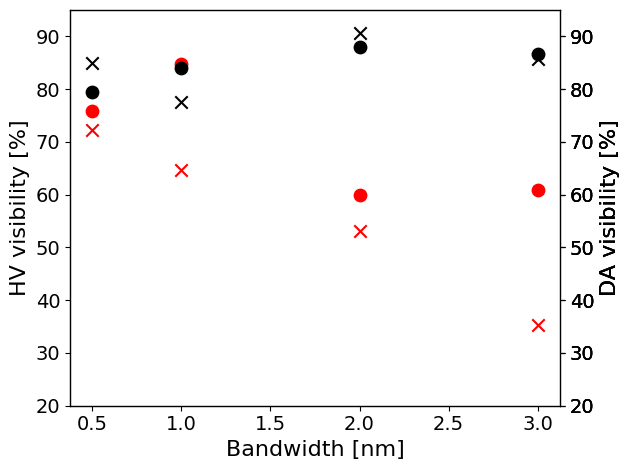

In [1]:
import matplotlib.pyplot as plt

# Data
bandwidth = [0.5, 1, 2, 3]
hv_visibility = [75.8, 84.8, 60, 60.9]
da_visibility = [72.2, 64.6, 53.1, 35.3]

hv_visibility_ref = [79.4, 84.1, 87.9, 86.7]
da_visibility_ref = [85.0, 77.6, 90.6, 85.7]

# Plot
fig, ax1 = plt.subplots()

ax1.scatter(bandwidth, hv_visibility, label='HV visibility', s=80, color='r')
ax1.set_ylim(20, 95)
ax1.tick_params(axis='both', labelsize=14)
ax1.set_xlabel('Bandwidth [nm]', fontsize=16)
ax1.set_ylabel('HV visibility [%]', fontsize=16)

ax2 = ax1.twinx()
ax2.scatter(bandwidth, da_visibility, label='DA visibility', s=80, marker='x', color='r')
ax2.set_ylim(20, 95)
ax2.tick_params(axis='both', labelsize=14)
ax2.set_ylabel('DA visibility [%]', fontsize=16)

ax3 = ax1.twinx()
ax3.scatter(bandwidth, hv_visibility_ref, label='DA visibility', s=80, color='k')
ax3.set_ylim(20, 95)
ax3.tick_params(axis='both', labelsize=14)
ax3.set_ylabel('DA visibility [%]', fontsize=16)

ax4 = ax1.twinx()
ax4.scatter(bandwidth, da_visibility_ref, label='DA visibility', s=80, marker='x', color='k')
ax4.set_ylim(20, 95)
ax4.tick_params(axis='both', labelsize=14)
ax4.set_ylabel('DA visibility [%]', fontsize=16)

# plt.title('Visibility vs Bandwidth (Dual Y-Axis Dot Plot)')
plt.tight_layout()
plt.show()


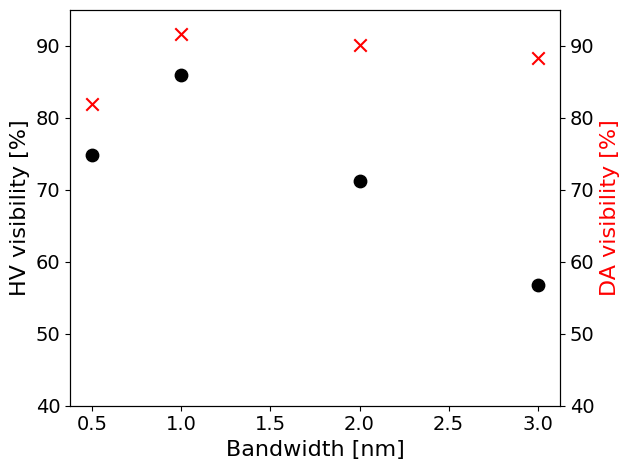

In [2]:
# Data
bandwidth = [0.5, 1, 2, 3]
hv_visibility = [74.8, 86.0, 71.2, 56.8]
da_visibility = [81.9, 91.6, 90.2, 88.3]

# Plot
fig, ax1 = plt.subplots()

ax1.scatter(bandwidth, hv_visibility, label='HV visibility', s=80, color='k')
ax1.set_ylim(40, 95)
ax1.tick_params(axis='both', labelsize=14)
ax1.set_xlabel('Bandwidth [nm]', fontsize=16)
ax1.set_ylabel('HV visibility [%]', fontsize=16)

ax2 = ax1.twinx()
ax2.scatter(bandwidth, da_visibility, label='DA visibility', s=80, marker='x', color='r')
ax2.set_ylim(40, 95)
ax2.tick_params(axis='both', labelsize=14)
ax2.set_ylabel('DA visibility [%]', fontsize=16, color='r')

# plt.title('Visibility vs Bandwidth (Dual Y-Axis Dot Plot)')
plt.tight_layout()
plt.show()

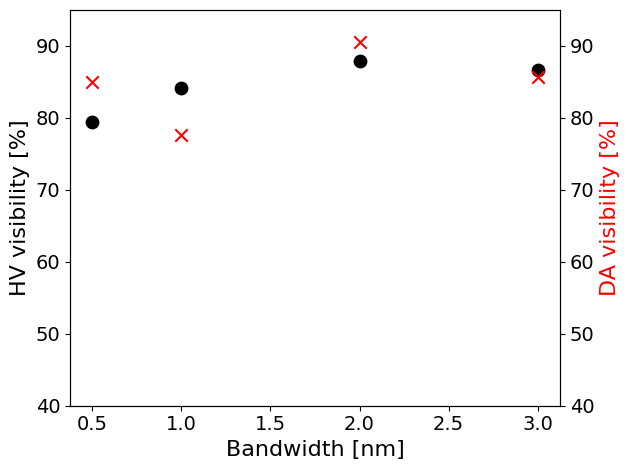

In [3]:
# Data
bandwidth = [0.5, 1, 2, 3]
hv_visibility = [79.4, 84.1, 87.9, 86.7]
da_visibility = [85.0, 77.6, 90.6, 85.7]

# Plot
fig, ax1 = plt.subplots()

ax1.scatter(bandwidth, hv_visibility, label='HV visibility', s=80, color='k')
ax1.set_ylim(40, 95)
ax1.tick_params(axis='both', labelsize=14)
ax1.set_xlabel('Bandwidth [nm]', fontsize=16)
ax1.set_ylabel('HV visibility [%]', fontsize=16)

ax2 = ax1.twinx()
ax2.scatter(bandwidth, da_visibility, label='DA visibility', s=80, marker='x', color='r')
ax2.set_ylim(40, 95)
ax2.tick_params(axis='both', labelsize=14)
ax2.set_ylabel('DA visibility [%]', fontsize=16, color='r')

# plt.title('Visibility vs Bandwidth (Dual Y-Axis Dot Plot)')
plt.tight_layout()
plt.show()

data
 [[ 1.          0.          0.          0.        ]
 [ 0.          0.99016375  0.13110739 -0.04885281]
 [ 0.         -0.11764959  0.96917909  0.2164497 ]
 [ 0.          0.07572527 -0.20857313  0.97507073]]


'Mueller_retar_test_01_260506.png'

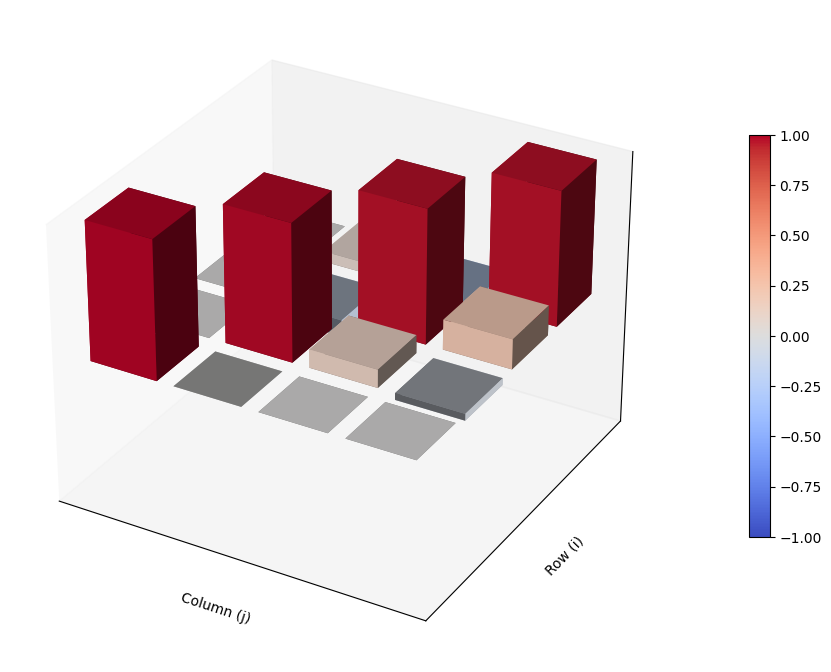

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

file_name = "Mueller_retar_test_01_260506"
# Load the 4x4 matrix again
csv_path = file_name + ".csv"
# csv_path = "Test_raw_Mueller_05.csv"
df = pd.read_csv(csv_path, header=None)
M_t = df.iloc[:4, :4].to_numpy(dtype=float)
M = M_t.T
print("data\n", M)
# Prepare coordinates
n = 4
x, y = np.meshgrid(np.arange(n), np.arange(n), indexing="xy")
x = x.ravel()
y = y.ravel()
z = np.zeros_like(x, dtype=float)
dz = M.ravel()

# Fixed z axis range
zmin, zmax = -1, 1

# Create the 3D figure
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

# Normalize to fixed range and use coolwarm colormap
norm = plt.Normalize(zmin, zmax)
colors = plt.cm.coolwarm(norm(dz))

# Plot bars
dx = dy = 0.8
ax.bar3d(x, y, z, dx, dy, dz, color=colors, shade=True)

# Remove all axis labels and ticks
ax.set_xlabel("Column (j)")
ax.set_ylabel("Row (i)")
ax.set_zlabel("")
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

# Set z-axis limits
ax.set_zlim(zmin, zmax)

# Add colorbar for coolwarm colormap
mappable = plt.cm.ScalarMappable(cmap="coolwarm", norm=norm)
mappable.set_array([])
cbar = plt.colorbar(mappable, ax=ax, shrink=0.6, pad=0.1)
# cbar.set_label("Matrix Value", rotation=270, labelpad=15)

# Title
# ax.set_title("4×4 Matrix Visualization (coolwarm colormap, z ∈ [-1, 1])")
plt.tight_layout()

out_path = file_name + ".png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
out_path


data
 [[ 1.         -0.02964043  0.00242954  0.00546647]
 [-0.02623907  0.64480078 -0.18707483  0.78000486]
 [ 0.01457726  0.45432459 -0.71610787 -0.56086006]
 [-0.00145773  0.61297376  0.64941691 -0.37536443]]


C:\Users\Jaedeok Park\AppData\Local\Temp\ipykernel_29340\3710038541.py:62: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


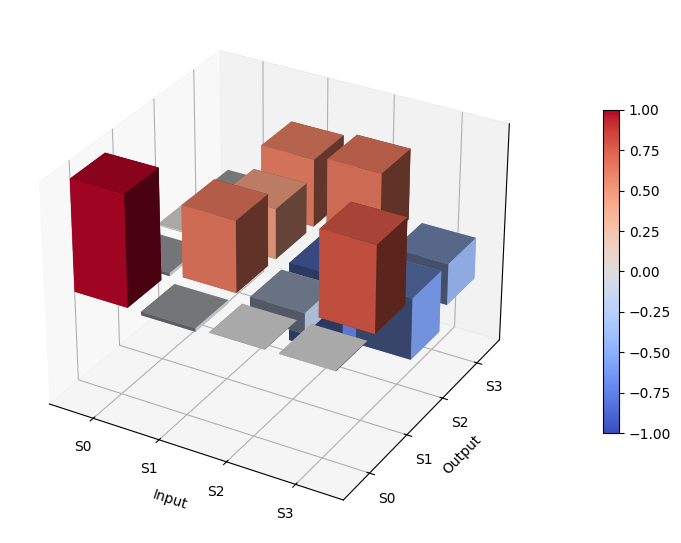

Mueller_total_test_02_260506.png


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

file_name = "Mueller_total_test_02_260506"

# Load the 4x4 matrix again
csv_path = file_name + ".csv"
df = pd.read_csv(csv_path, header=None)
M_t = df.iloc[:4, :4].to_numpy(dtype=float)
M = M_t.T
print("data\n", M)

# Prepare coordinates
n = 4
x, y = np.meshgrid(np.arange(n), np.arange(n), indexing="xy")
x = x.ravel()
y = y.ravel()
z = np.zeros_like(x, dtype=float)
dz = M.ravel()

# Fixed z axis range
zmin, zmax = -1, 1

# Create the 3D figure
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

# Normalize to fixed range and use coolwarm colormap
norm = plt.Normalize(zmin, zmax)
colors = plt.cm.coolwarm(norm(dz))

# Plot bars
dx = dy = 0.8
ax.bar3d(x, y, z, dx, dy, dz, color=colors, shade=True)

# Axis labels
ax.set_xlabel("Input")
ax.set_ylabel("Output")
ax.set_zlabel("")

# Tick positions: bar 중심에 오도록 0.4 더함
tick_pos = np.arange(n) + dx / 2
tick_labels = ["S0", "S1", "S2", "S3"]

ax.set_xticks(tick_pos)
ax.set_yticks(tick_pos)
ax.set_xticklabels(tick_labels)
ax.set_yticklabels(tick_labels)

# z축 tick은 숨김
ax.set_zticks([])

# Set z-axis limits
ax.set_zlim(zmin, zmax)

# Add colorbar
mappable = plt.cm.ScalarMappable(cmap="coolwarm", norm=norm)
mappable.set_array([])
cbar = plt.colorbar(mappable, ax=ax, shrink=0.6, pad=0.1)

plt.tight_layout()

out_path = file_name + ".png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()

print(out_path)

data
 [[ 1.         -0.11217734 -0.0463816  -0.05293395]
 [ 0.          0.72664598  0.02630395 -0.01307857]
 [ 0.          0.02630395  0.7496754  -0.0932428 ]
 [ 0.         -0.01307857 -0.0932428   0.86989308]]


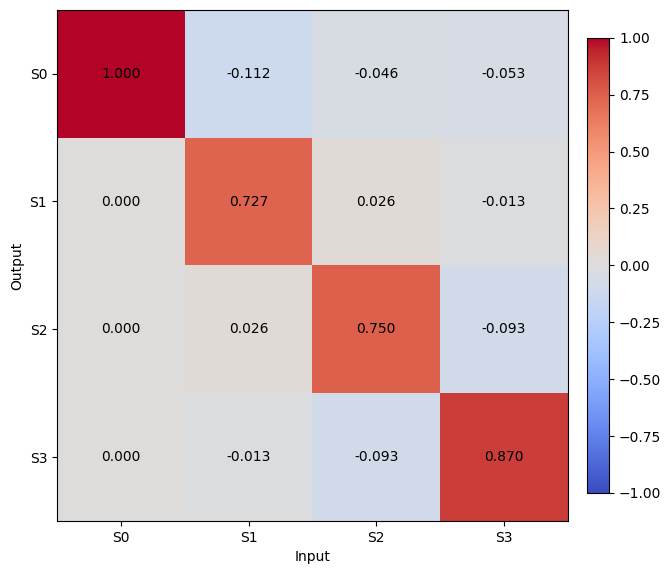

Mueller_depol_PMF1m_260507_topview.png


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

file_name = "Mueller_depol_PMF1m_260507"

# Load the 4x4 matrix
csv_path = file_name + ".csv"
df = pd.read_csv(csv_path, header=None)
M_t = df.iloc[:4, :4].to_numpy(dtype=float)
M = M_t.T
print("data\n", M)

labels = ["S0", "S1", "S2", "S3"]

fig, ax = plt.subplots(figsize=(7, 6))

# top view heatmap
im = ax.imshow(
    M,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    origin="upper"   # (0,0)을 왼쪽 위로
)

# x, y tick labels
ax.set_xticks(np.arange(4))
ax.set_yticks(np.arange(4))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

# axis labels
ax.set_xlabel("Input")
ax.set_ylabel("Output")

# 각 칸에 값 표시
for i in range(4):       # row = y
    for j in range(4):   # col = x
        value = M[i, j]
        ax.text(
            j, i, f"{value:.3f}",
            ha="center",
            va="center",
            color="black"
        )

# colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.85, pad=0.03)

plt.tight_layout()

out_path = file_name + "_topview.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()

print(out_path)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_poincare_sphere(point, elev=20, azim=35):
    """
    point: (S1, S2, S3), DoP=1인 점이라고 가정
    """

    s1, s2, s3 = point
    r = np.sqrt(s1**2 + s2**2 + s3**2)

    if not np.isclose(r, 1.0, atol=1e-8):
        raise ValueError(f"DoP must be 1. Got norm = {r}")

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')

    # -----------------------------
    # Sphere surface (mesh)
    # -----------------------------
    u = np.linspace(0, 2*np.pi, 80)
    v = np.linspace(0, np.pi, 40)

    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))

    ax.plot_surface(
        x, y, z,
        rstride=2, cstride=2,
        edgecolor='gray',
        linewidth=0.4,
        alpha=0.2
    )

    # -----------------------------
    # Axis lines
    # -----------------------------
    ax.plot([-1.2, 1.2], [0, 0], [0, 0], color='k', linewidth=1.2)
    ax.plot([0, 0], [-1.2, 1.2], [0, 0], color='k', linewidth=1.2)
    ax.plot([0, 0], [0, 0], [-1.2, 1.2], color='k', linewidth=1.2)

    # -----------------------------
    # Polarization point
    # -----------------------------
    ax.scatter(
        [s1], [s2], [s3],
        color='k',
        marker='^',   # black triangle
        s=120,
        depthshade=False
    )

    # Optional: origin to point line
    ax.plot([0, s1], [0, s2], [0, s3], color='k', linestyle='--', linewidth=1.0)

    # -----------------------------
    # Axis labels only
    # -----------------------------
    # ax.set_xlabel("S1", fontsize=14, labelpad=12)
    # ax.set_ylabel("S2", fontsize=14, labelpad=12)
    # ax.set_zlabel("S3", fontsize=14, labelpad=12)

    # -----------------------------
    # Remove tick labels
    # -----------------------------
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

    # -----------------------------
    # Limits and aspect
    # -----------------------------
    ax.set_xlim([-1.2, 1.2])
    ax.set_ylim([-1.2, 1.2])
    ax.set_zlim([-1.2, 1.2])
    ax.set_box_aspect([1, 1, 1])

    # Remove pane background if desired
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False

    # View angle
    ax.view_init(elev=elev, azim=azim)

    plt.tight_layout()
    plt.show()


# Example point on the sphere (DoP = 1)
# point = (1/np.sqrt(3), -1/np.sqrt(3), +1/np.sqrt(3))
point = (0,1,0)
plot_poincare_sphere(point)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_poincare_sphere_clean(point):
    s1, s2, s3 = point
    r = np.linalg.norm(point)

    if not np.isclose(r, 1.0, atol=1e-8):
        raise ValueError("Input point must satisfy DoP = 1.")

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Sphere mesh
    u = np.linspace(0, 2*np.pi, 100)
    v = np.linspace(0, np.pi, 50)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))

    ax.plot_surface(
        x, y, z,
        edgecolor='gray',
        linewidth=0.3,
        alpha=0.7
    )

    # Axes
    lim = 1.15
    ax.plot([-lim, lim], [0, 0], [0, 0], color='k', linewidth=1)
    ax.plot([0, 0], [-lim, lim], [0, 0], color='k', linewidth=1)
    ax.plot([0, 0], [0, 0], [-lim, lim], color='k', linewidth=1)

    # Point
    ax.scatter(s1, s2, s3, color='k', marker='^', s=140, depthshade=False)

    # Labels only
    ax.set_xlabel("S1", fontsize=14, labelpad=10)
    ax.set_ylabel("S2", fontsize=14, labelpad=10)
    ax.set_zlabel("S3", fontsize=14, labelpad=10)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_zlim(-1.1, 1.1)
    ax.set_box_aspect([1, 1, 1])

    # pane/background off
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.grid(False)

    plt.tight_layout()
    plt.show()

plot_poincare_sphere_clean((0, 0, 1))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_poincare_sphere_with_trajectory(
    stokes_vectors=None,
    show_reference_points=True,
    show_reference_labels=True,
    trajectory_marker='o',
    elev=20,
    azim=35,
    sphere_alpha=0.1
):
    """
    Plot a Poincare sphere with:
      - transparent mesh sphere
      - centered S1, S2, S3 axes only
      - H, V, D, A, R, L reference points
      - optional trajectory from input Stokes vectors

    Parameters
    ----------
    stokes_vectors : array-like, shape (N,3) or (3,)
        Array of [S1, S2, S3] points.
        If shape is (3,), it is treated as a single point.
    show_reference_points : bool
        Whether to show H, V, D, A, R, L points.
    show_reference_labels : bool
        Whether to annotate H, V, D, A, R, L.
    trajectory_marker : str
        Marker used for trajectory points.
    elev, azim : float
        View angles for 3D plot.
    sphere_alpha : float
        Transparency of sphere surface.
    """

    fig = plt.figure(figsize=(9, 9))
    ax = fig.add_subplot(111, projection='3d')

    u = np.linspace(0, 2*np.pi, 120)
    v = np.linspace(0, np.pi, 60)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))

    ax.plot_surface(
        x, y, z,
        edgecolor='gray',
        linewidth=0.3,
        alpha=sphere_alpha
    )

    axis_len = 1.15
    ax.plot([-axis_len, axis_len], [0, 0], [0, 0], color='k', linewidth=1.2)
    ax.plot([0, 0], [-axis_len, axis_len], [0, 0], color='k', linewidth=1.2)
    ax.plot([0, 0], [0, 0], [-axis_len, axis_len], color='k', linewidth=1.2)

    # Axis-end labels
    label_offset = 1.4
    ax.text(label_offset, 0, 0, "H", fontsize=14, ha='center', va='center')
    ax.text(0, label_offset, 0, "D", fontsize=14, ha='center', va='center')
    ax.text(0, 0, label_offset, "R", fontsize=14, ha='center', va='center')
    ax.text(-label_offset, 0, 0, "V", fontsize=14, ha='center', va='center')
    ax.text(0, -label_offset, 0, "A", fontsize=14, ha='center', va='center')
    ax.text(0, 0, -label_offset, "L", fontsize=14, ha='center', va='center')

    ref_points = {
        "H": ( 1,  0,  0),
        "V": (-1,  0,  0),
        "D": ( 0,  1,  0),
        "A": ( 0, -1,  0),
        "R": ( 0,  0,  1),
        "L": ( 0,  0, -1),
    }

    if stokes_vectors is not None:
        stokes_vectors = np.asarray(stokes_vectors, dtype=float)

        if stokes_vectors.ndim == 1:
            if stokes_vectors.shape[0] != 3:
                raise ValueError("If 1D input is used, it must have shape (3,).")
            stokes_vectors = stokes_vectors.reshape(1, 3)

        if stokes_vectors.ndim != 2 or stokes_vectors.shape[1] != 3:
            raise ValueError("stokes_vectors must have shape (N,3) or (3,)")

        s1 = stokes_vectors[:, 0]
        s2 = stokes_vectors[:, 1]
        s3 = stokes_vectors[:, 2]

        # trajectory line
        ax.plot(s1, s2, s3, linewidth=1.8)

        # trajectory points
        ax.scatter(
            s1, s2, s3,
            marker=trajectory_marker,
            s=35,
            depthshade=False
        )

        # first and last points emphasized
        ax.scatter(
            [s1[0]], [s2[0]], [s3[0]],
            color='k',
            marker='s',
            s=70,
            depthshade=False
        )
        ax.scatter(
            [s1[-1]], [s2[-1]], [s3[-1]],
            color='k',
            marker='*',
            s=130,
            depthshade=False
        )

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_zlabel("")

    ax.grid(False)

    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False

    ax.xaxis.pane.set_edgecolor((1, 1, 1, 1))
    ax.yaxis.pane.set_edgecolor((1, 1, 1, 1))
    ax.zaxis.pane.set_edgecolor((1, 1, 1, 0))
    ax.set_axis_off()

    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        axis._axinfo["grid"]["linewidth"] = 0
        axis._axinfo["tick"]["inward_factor"] = 0
        axis._axinfo["tick"]["outward_factor"] = 0
        axis._axinfo["axisline"]["linewidth"] = 0


    lim = 1.28
    ax.set_xlim([-lim, lim])
    ax.set_ylim([-lim, lim])
    ax.set_zlim([-lim, lim])
    ax.set_box_aspect([1, 1, 1])
    ax.view_init(elev=elev, azim=azim)

    plt.tight_layout()
    plt.show()

In [ ]:
S = np.array([
    [0.95, 0.05, 0.00],
    [0.85, 0.20, 0.10],
    [0.60, 0.50, 0.20],
    [0.20, 0.80, 0.30],
    [0.00, 0.90, 0.40],
])

plot_poincare_sphere_with_trajectory(stokes_vectors=S)

In [ ]:
import plot_Poincare as Poincare
import numpy as np
import matplotlib.pyplot as plt

S = np.array([
    [0.95, 0.05, 0.00],
    [0.85, 0.20, 0.10],
    [0.60, 0.50, 0.20],
    [0.20, 0.80, 0.30],
    [0.00, 0.90, 0.40],
])

In [ ]:
QWP2_trace_raw = np.loadtxt("Test_Tomo_QWP2_20260429.csv", delimiter = ",", dtype = complex)
print(QWP2_trace_raw.shape)
QWP2_trace = QWP2_trace_raw[5:,1:4]
print(QWP2_trace.shape)

In [ ]:
Poincare.plot_Poincare(stokes_vectors = QWP2_trace[:, :], trajectory_marker='.', elev = -10, azim = 5)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import plot_Poincare as poincare

# Raw = [-1.5391255, 0.0055499849]

# Raw = np.array([-1.5391255, 0.0055499849])
# Raw_deg = Raw * 180.0 / np.pi

# Stokes_vector = np.array([np.cos(2 * Raw[0]) * np.cos(2 * Raw[0]), 
#                           np.sin(2 * Raw[0]) * np.cos(2 * Raw[1]), 
#                           np.sin(2 * Raw[1])])

# Stokes_wrong = [np.float64(0.9959931978737325), np.float64(-0.06329540639840021), np.float64(0.011099741864764657)]

Stokes_ref = np.array([
    [0.95, 0.00, 0.00],
    [0.85, 0.20, 0.10],
    [0.60, 0.50, 0.20],
    [0.20, 0.80, 0.30],
    [0.00, 0.90, 0.40],
    [0.50, 0.00, 0.00],
])

# print(Stokes_ref.shape[0])
# Stokes_norm = np.zeros([Stokes_ref.shape[0], 3])
# for aaa in range(Stokes_ref.shape[0]):
#     Stokes_norm[aaa,:] = Stokes_ref[aaa,:] / np.sqrt(Stokes_ref[aaa,0]**2 + Stokes_ref[aaa,1]**2 + Stokes_ref[aaa,2]**2)




# Stokes_ref = [1, 0, 0]
# print(Raw)
# print(Raw_deg)
# print(Stokes_vector)
# print(Stokes_wrong)




# poincare.plot_Poincare(stokes_vectors = Stokes_vector, trajectory_marker = '.')

poincare.plot_Poincare(stokes_vectors = Stokes_ref, trajectory_marker = '.')
# poincare.plot_Poincare(stokes_vectors = Stokes_norm, trajectory_marker = '.')

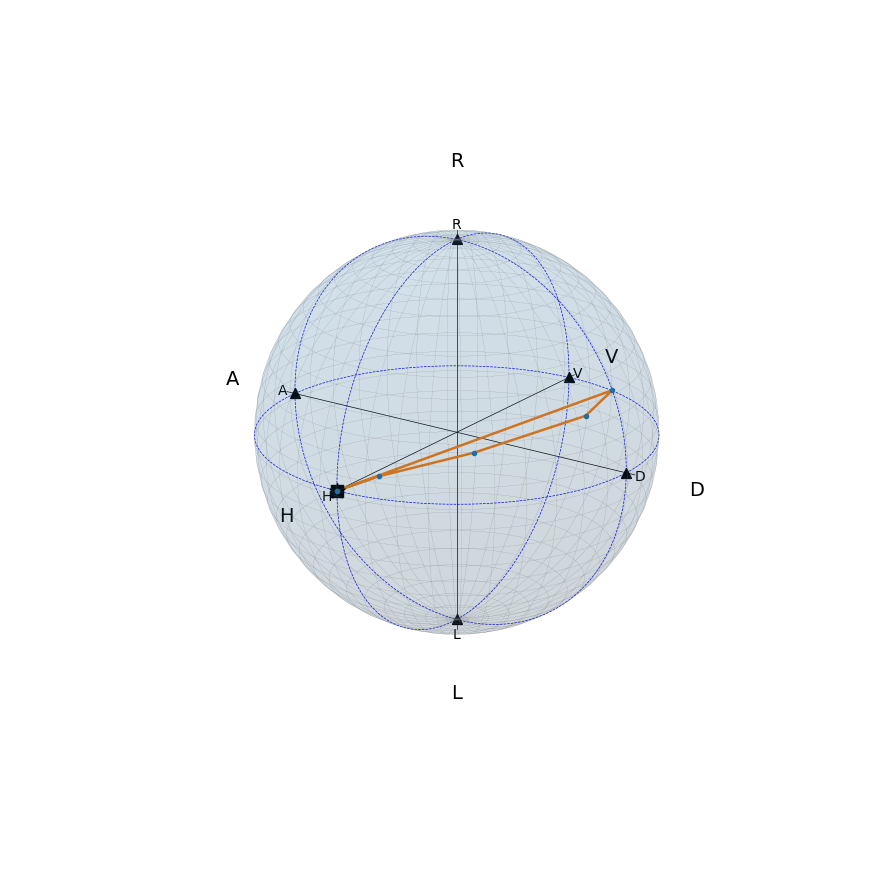

(<Figure size 900x900 with 1 Axes>, <Axes3D: >)

In [2]:
import numpy as np
# from PoincarePlotter import PoincarePlot
import PoincarePlotter as poinplt

Figure = poinplt.PoincarePlot()

Stokes_ref = np.array([
    [0.95, 0.00, 0.00],
    [0.85, 0.20, 0.10],
    [0.60, 0.50, 0.20],
    [0.20, 0.80, 0.30],
    [0.00, 0.90, 0.40],
    [0.50, 0.00, 0.00],
])



Figure.plot_poincare(Stokes_ref)